# 15S-15N OLR, Kelvin, Rossby, and MJO Hovmoller diagrams

This notebook creates a four-panel longitude-time Hovmoller figure using the
arithmetic latitude mean over 15S-15N. Longitude remains in its original
0-360 degree coordinate, so no event-centered longitude composite is applied.

Panels:

1. Raw daily OLR with dashed Kelvin, ER/Rossby, and MJO filtered contours.
2. Kelvin-filtered OLR.
3. Equatorial-Rossby-filtered OLR.
4. MJO-filtered OLR.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display
import cckw_olr_analysis as cckw


In [2]:
# -------------------------------------------------------------------------
# User settings
# -------------------------------------------------------------------------
PLOT_START = "2020-01-02"
PLOT_END = "2020-03-20"

LAT_MIN = -15.0
LAT_MAX = 15.0

# Optional horizontal date marker. Set to None to remove it.
EVENT_DATE = "2020-01-12"

FILTER_START = "1980-01-01"
FILTER_END = "2022-12-31"
KELVIN_PERIOD_DAYS = (2.5, 20.0)
KELVIN_WAVENUMBER = (1, 14)
ER_PERIOD_DAYS = (6.25, 48)
ER_WAVENUMBER = (-10, -1)
MJO_PERIOD_DAYS = (30.0, 96.0)
MJO_WAVENUMBER = (1, 5)

# Each mode is overlaid at its own negative 1.5-sigma threshold so that Kelvin,
# ER/Rossby, and MJO are all visible after the broad 15S-15N latitude mean.
OVERLAY_SIGMA_MULTIPLIER = 1.5
FORCE_FILTER = False
N_WORKERS = 4
N_HARM = 3

OUTPUT_DIR = Path("/Users/lipu/Desktop/code/wave_hovmoller_15S15N_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "mplconfig").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "xdg_cache").mkdir(parents=True, exist_ok=True)

TAG = cckw.filter_tag(FILTER_START, FILTER_END, KELVIN_PERIOD_DAYS, KELVIN_WAVENUMBER)
KELVIN_PATH = cckw.filtered_output_path(FILTER_START, FILTER_END, KELVIN_PERIOD_DAYS, KELVIN_WAVENUMBER)
ER_PATH = cckw.wave_filtered_output_path("er", FILTER_START, FILTER_END, ER_PERIOD_DAYS, ER_WAVENUMBER)
MJO_PATH = cckw.wave_filtered_output_path("mjo", FILTER_START, FILTER_END, MJO_PERIOD_DAYS, MJO_WAVENUMBER)
FIGURE_PATH = OUTPUT_DIR / f"olr_kelvin_rossby_mjo_hovmoller_{PLOT_START}_{PLOT_END}_{TAG}.png"

print("Plot period:", PLOT_START, "to", PLOT_END)
print("Latitude mean:", f"{abs(LAT_MIN):g}S-{LAT_MAX:g}N")
print("Absolute longitude coordinate: 0-360 degrees")


Plot period: 2020-01-02 to 2020-03-20
Latitude mean: 15S-15N
Absolute longitude coordinate: 0-360 degrees


In [3]:
def lat_mean(da: xr.DataArray) -> xr.DataArray:
    band = da.sortby("lat").sel(lat=slice(LAT_MIN, LAT_MAX))
    return band.mean("lat")


def cyclic_lon_values(da: xr.DataArray) -> tuple[np.ndarray, np.ndarray]:
    da = da.assign_coords(lon=(da.lon % 360.0)).sortby("lon")
    lon = da.lon.values.astype(float)
    values = np.asarray(da.values, dtype=float)
    return np.r_[lon, 360.0], np.concatenate([values, values[:, :1]], axis=1)


def robust_symmetric_limit(*arrays: xr.DataArray, percentile: float = 99.0, minimum: float = 16.0) -> float:
    values = []
    for da in arrays:
        flat = np.asarray(da.values, dtype=float)
        flat = flat[np.isfinite(flat)]
        if flat.size:
            values.append(np.nanpercentile(np.abs(flat), percentile))
    return max(minimum, float(np.nanmax(values)))


def negative_sigma_level(values: np.ndarray) -> float:
    return -OVERLAY_SIGMA_MULTIPLIER * float(np.nanstd(values))


def open_or_compute_filters() -> tuple[xr.DataArray, xr.DataArray, xr.DataArray]:
    paths = [KELVIN_PATH, ER_PATH, MJO_PATH]
    if all(path.exists() for path in paths) and not FORCE_FILTER:
        return tuple(xr.open_dataarray(path) for path in paths)

    ds_full = xr.open_dataset(cckw.OLR_PATH)
    olr_full = (
        ds_full["olr"]
        .sortby("lat")
        .sel(time=slice(FILTER_START, FILTER_END), lat=slice(LAT_MIN, LAT_MAX))
        .transpose("time", "lat", "lon")
        .load()
    )
    olr_full = cckw.fill_missing_olr(olr_full)

    kelvin_full = cckw.run_kelvin_filter(
        olr_full,
        force=FORCE_FILTER,
        n_workers=N_WORKERS,
        n_harm=N_HARM,
        period_days=KELVIN_PERIOD_DAYS,
        wavenumber=KELVIN_WAVENUMBER,
        output_path=KELVIN_PATH,
    )
    er_full = cckw.run_wave_filter(
        olr_full,
        wave_name="er",
        period_days=ER_PERIOD_DAYS,
        wavenumber=ER_WAVENUMBER,
        force=FORCE_FILTER,
        n_workers=N_WORKERS,
        n_harm=N_HARM,
        output_path=ER_PATH,
        equiv_depth=(8.0, 90.0),
        meridional_mode=1,
        dispersion_family="er",
    )
    mjo_full = cckw.run_wave_filter(
        olr_full,
        wave_name="mjo",
        period_days=MJO_PERIOD_DAYS,
        wavenumber=MJO_WAVENUMBER,
        force=FORCE_FILTER,
        n_workers=N_WORKERS,
        n_harm=N_HARM,
        output_path=MJO_PATH,
    )
    return kelvin_full, er_full, mjo_full


In [4]:
# Raw daily OLR is loaded only for the requested plotting period.
ds = xr.open_dataset(cckw.OLR_PATH)
raw_olr = (
    ds["olr"]
    .sortby("lat")
    .sel(time=slice(PLOT_START, PLOT_END), lat=slice(LAT_MIN, LAT_MAX))
    .transpose("time", "lat", "lon")
    .load()
)

kelvin_full, er_full, mjo_full = open_or_compute_filters()
kelvin = kelvin_full.sel(time=slice(PLOT_START, PLOT_END), lat=slice(LAT_MIN, LAT_MAX)).load()
er = er_full.sel(time=slice(PLOT_START, PLOT_END), lat=slice(LAT_MIN, LAT_MAX)).load()
mjo = mjo_full.sel(time=slice(PLOT_START, PLOT_END), lat=slice(LAT_MIN, LAT_MAX)).load()

raw_hov = lat_mean(raw_olr)
kelvin_hov = lat_mean(kelvin)
er_hov = lat_mean(er)
mjo_hov = lat_mean(mjo)

print(raw_hov)


<xarray.DataArray 'olr' (time: 79, lon: 144)> Size: 46kB
array([[266.30768, 260.6423 , 258.75   , ..., 269.48846, 269.6346 ,
        271.88077],
       [265.05768, 252.13077, 241.21153, ..., 264.85   , 265.44232,
        266.3654 ],
       [257.90384, 257.11154, 250.8077 , ..., 267.08844, 263.82693,
        263.87308],
       ...,
       [229.71153, 233.18848, 233.25   , ..., 257.33463, 250.82692,
        229.50768],
       [213.53847, 209.43846, 201.82692, ..., 253.53078, 246.76923,
        238.43076],
       [234.65384, 230.33847, 218.78847, ..., 263.08075, 253.72116,
        239.29614]], dtype=float32)
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 632B 2020-01-02 2020-01-03 ... 2020-03-20


/Users/lipu/Desktop/code/wave_hovmoller_15S15N_output/olr_kelvin_rossby_mjo_hovmoller_2020-01-02_2020-03-20_1980-01-01_2022-12-31_p2p5-20_k1-14.png


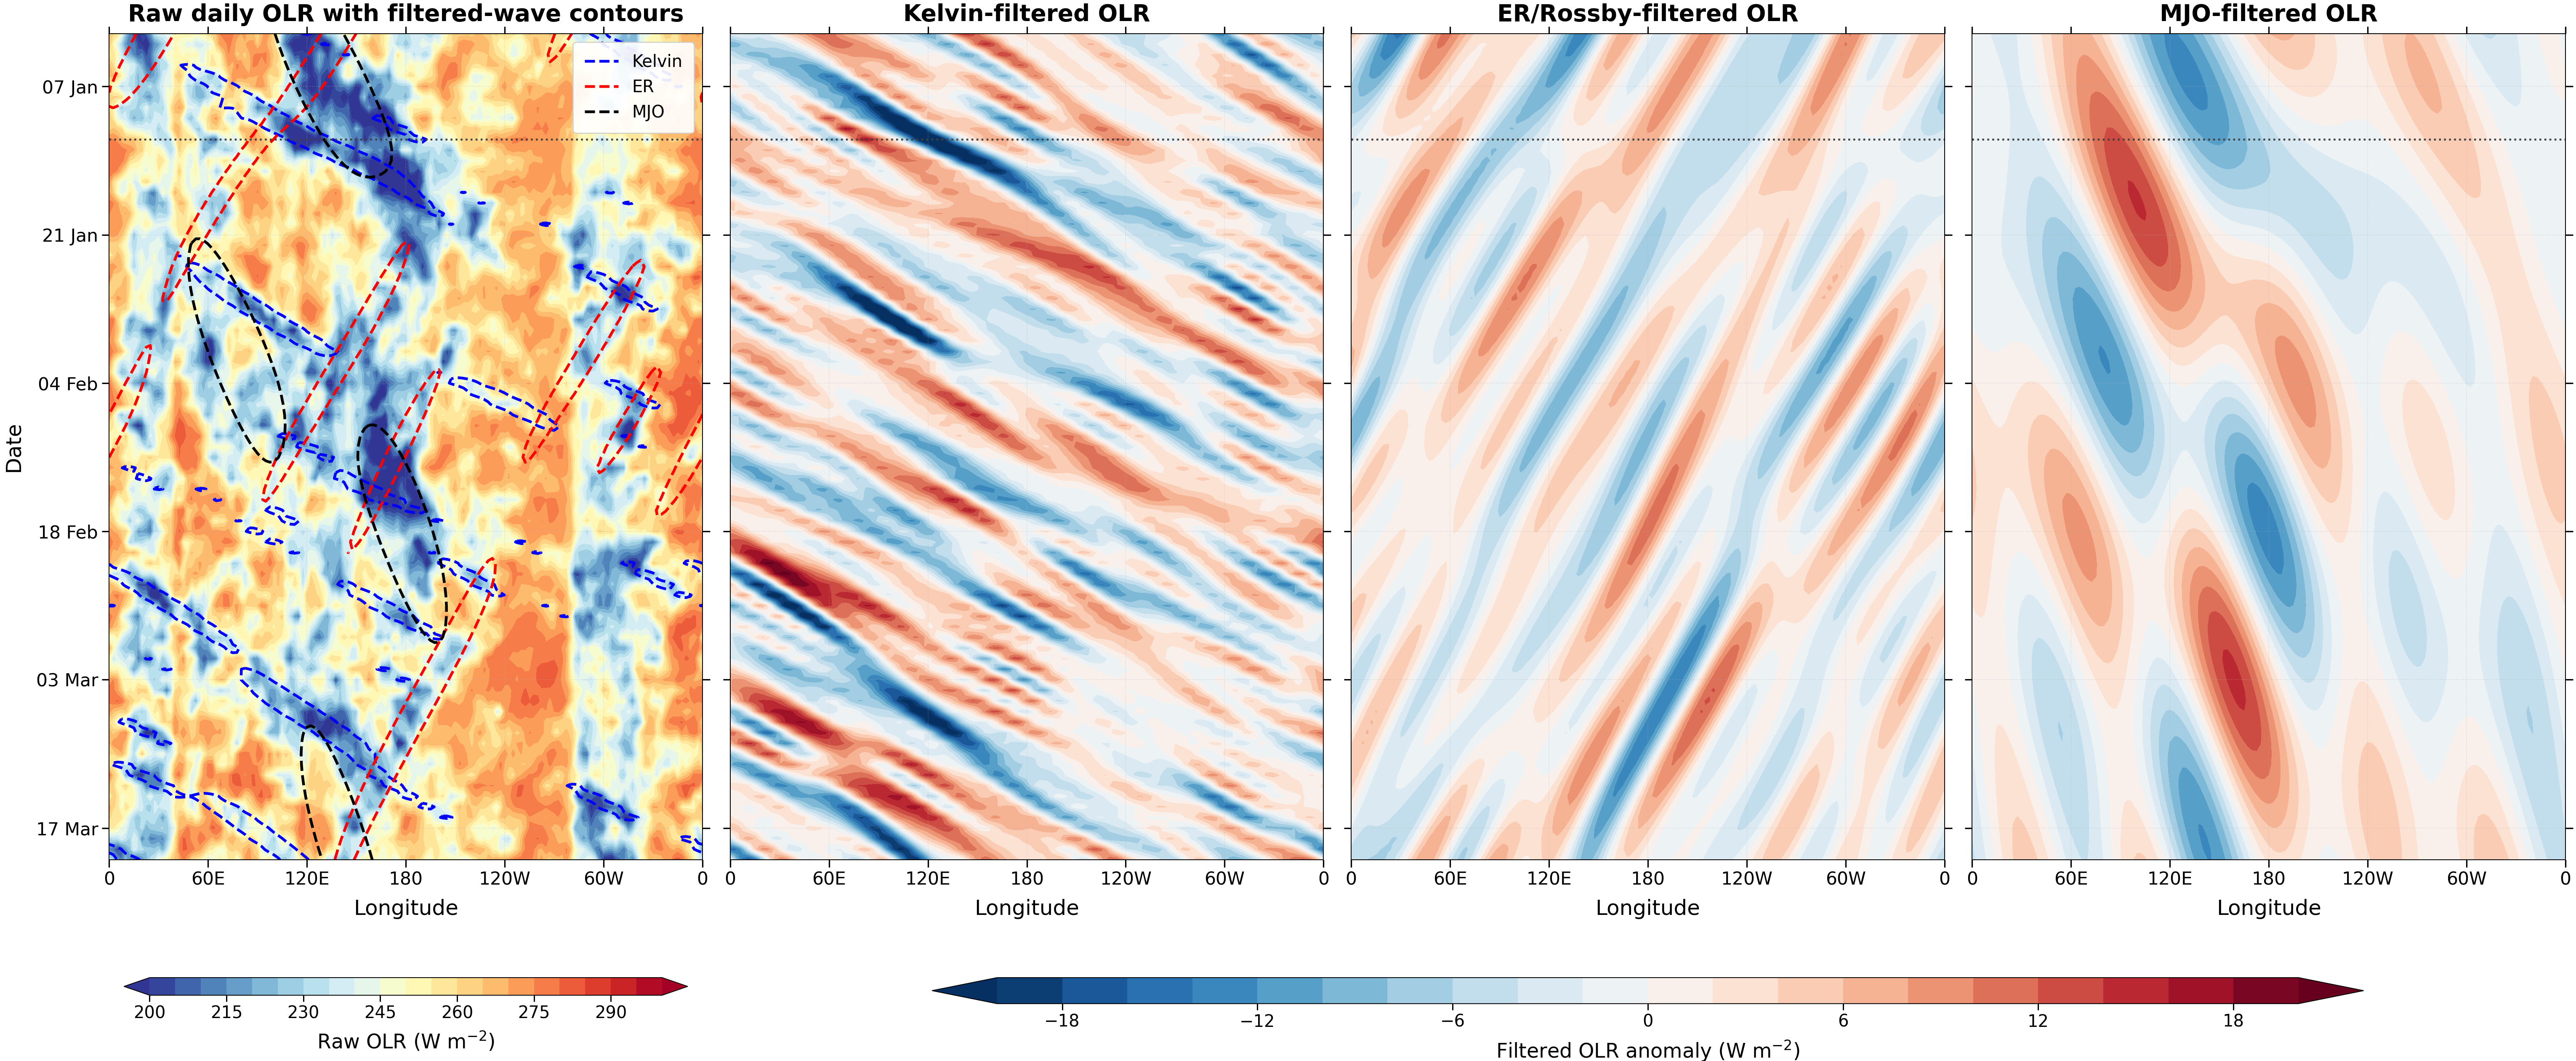

In [5]:
def plot_four_panel_hovmoller(
    raw: xr.DataArray,
    kelvin: xr.DataArray,
    er: xr.DataArray,
    mjo: xr.DataArray,
    save_path: Path,
) -> None:
    dates = pd.to_datetime(raw.time.values)
    lon_raw, raw_values = cyclic_lon_values(raw)
    lon_kelvin, kelvin_values = cyclic_lon_values(kelvin)
    lon_er, er_values = cyclic_lon_values(er)
    lon_mjo, mjo_values = cyclic_lon_values(mjo)

    filter_limit = robust_symmetric_limit(kelvin, er, mjo)
    filter_levels = np.linspace(-20, 20, 21)
    raw_min = float(np.nanpercentile(raw_values, 1.0))
    raw_max = float(np.nanpercentile(raw_values, 99.0))
    raw_levels = np.linspace(200, 300, 21)

    title_size = 22
    label_size = 20
    tick_size = 17
    legend_size = 16
    colorbar_label_size = 19
    colorbar_tick_size = 16

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(34, 14),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    ax_raw, ax_kelvin, ax_er, ax_mjo = axes

    raw_mesh = ax_raw.contourf(
        lon_raw,
        dates,
        raw_values,
        levels=raw_levels,
        cmap="RdYlBu_r",
        extend="both",
    )

    overlay_specs = [
        ("Kelvin", lon_kelvin, kelvin_values, "blue", negative_sigma_level(kelvin_values)),
        ("ER", lon_er, er_values, "red", negative_sigma_level(er_values)),
        ("MJO", lon_mjo, mjo_values, "black", negative_sigma_level(mjo_values)),
    ]
    for label, lon, values, color, level in overlay_specs:
        if np.nanmin(values) <= level <= np.nanmax(values):
            ax_raw.contour(
                lon,
                dates,
                values,
                levels=[level],
                colors=color,
                linestyles="--",
                linewidths=2.6,
            )

    filtered_panels = [
        (ax_kelvin, lon_kelvin, kelvin_values, "Kelvin-filtered OLR"),
        (ax_er, lon_er, er_values, "ER/Rossby-filtered OLR"),
        (ax_mjo, lon_mjo, mjo_values, "MJO-filtered OLR"),
    ]
    filter_mesh = None
    for ax, lon, values, title in filtered_panels:
        filter_mesh = ax.contourf(
            lon,
            dates,
            values,
            levels=filter_levels,
            cmap="RdBu_r",
            extend="both",
        )
        ax.set_title(title, fontsize=title_size, fontweight="bold", pad=12)

    ax_raw.set_title("Raw daily OLR with filtered-wave contours", fontsize=title_size, fontweight="bold", pad=12)
    legend_handles = [
        Line2D([0], [0], color=color, lw=2.6, ls="--", label=f"{label}")
        for label, lon, values, color, level in overlay_specs
    ]
    ax_raw.legend(
        handles=legend_handles,
        # title=f"Negative {OVERLAY_SIGMA_MULTIPLIER:g}$\sigma$ contours",
        loc="upper right",
        fontsize=legend_size,
        framealpha=0.92,
        borderpad=0.7,
    )

    if EVENT_DATE is not None:
        event_time = pd.Timestamp(EVENT_DATE)
        for ax in axes:
            ax.axhline(event_time, color="0.25", lw=1.8, ls=":")

    for ax in axes:
        ax.set_xlim(0, 360)
        ax.set_ylim(pd.Timestamp(PLOT_START), pd.Timestamp(PLOT_END))
        ax.invert_yaxis()
        ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
        ax.set_xticklabels(["0", "60E", "120E", "180", "120W", "60W", "0"])
        ax.yaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        ax.grid(True, ls=":", lw=0.8, alpha=0.35)
        ax.tick_params(top=True, right=True, labelsize=tick_size, length=7, width=1.3)
        ax.set_xlabel("Longitude", fontsize=label_size, labelpad=10)

    ax_raw.set_ylabel("Date", fontsize=label_size, labelpad=12)

    raw_cbar = fig.colorbar(
        raw_mesh,
        ax=ax_raw,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        aspect=32,
    )
    raw_cbar.set_label("Raw OLR (W m$^{-2}$)", fontsize=colorbar_label_size, labelpad=8)
    raw_cbar.ax.tick_params(labelsize=colorbar_tick_size, length=6, width=1.2)
    filter_cbar = fig.colorbar(
        filter_mesh,
        ax=[ax_kelvin, ax_er, ax_mjo],
        orientation="horizontal",
        pad=0.06,
        shrink=0.78,
        aspect=55,
    )
    filter_cbar.set_label("Filtered OLR anomaly (W m$^{-2}$)", fontsize=colorbar_label_size, labelpad=8)
    filter_cbar.ax.tick_params(labelsize=colorbar_tick_size, length=6, width=1.2)

  
    fig.savefig(save_path, dpi=180)
    plt.close(fig)


plot_four_panel_hovmoller(raw_hov, kelvin_hov, er_hov, mjo_hov, FIGURE_PATH)
print(FIGURE_PATH)
display(Image(filename=str(FIGURE_PATH)))


## Notes

- The first panel uses the original daily OLR field, not a longitude-centered
  composite.
- Dashed contours in the first panel show enhanced-convection signals using
  each mode's own negative 1.5-standard-deviation threshold.
- All four panels use the same absolute longitude axis.
- Change only `PLOT_START` and `PLOT_END` to examine another event period.
